In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [4]:
df = pd.read_csv(
    "dataset/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

print(df.shape)

(180519, 53)


In [5]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [6]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Customer Lname,8
Customer Zipcode,3
Order Zipcode,155679
Product Description,180519


In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
    cat_cols = df.select_dtypes(exclude=np.number).columns

/tmp/ipykernel_5351/1035985838.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [10]:
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_5351/3383984422.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
df.isnull().sum().sum()

np.int64(180519)

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [14]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (180519, 53)


In [15]:
print(df.duplicated().sum())

0


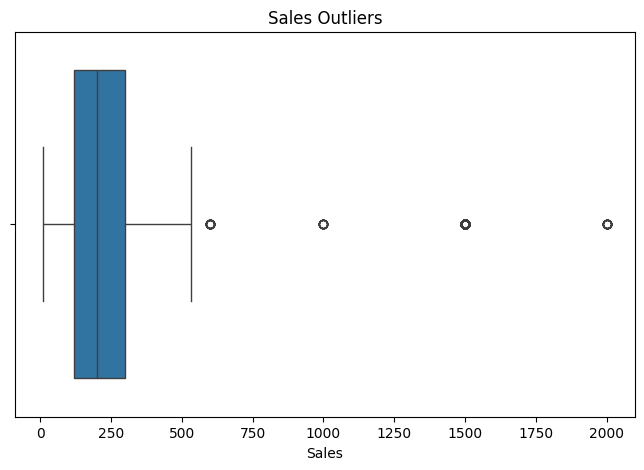

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sales'])

plt.title("Sales Outliers")
plt.show()

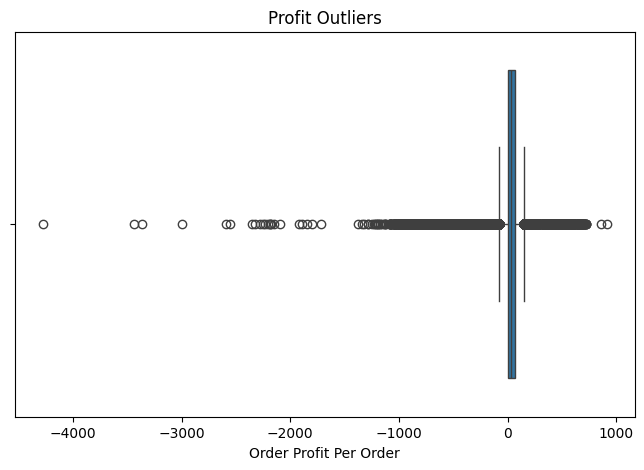

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Order Profit Per Order'])

plt.title("Profit Outliers")
plt.show()

In [19]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Sales'] >= lower) &
    (df['Sales'] <= upper)
]

In [20]:
Q1 = df['Order Profit Per Order'].quantile(0.25)
Q3 = df['Order Profit Per Order'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Order Profit Per Order'] >= lower) &
    (df['Order Profit Per Order'] <= upper)
]

In [21]:
print(df.shape)

(161423, 53)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161423 entries, 0 to 180516
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           161423 non-null  object 
 1   Days for shipping (real)       161423 non-null  int64  
 2   Days for shipment (scheduled)  161423 non-null  int64  
 3   Benefit per order              161423 non-null  float64
 4   Sales per customer             161423 non-null  float64
 5   Delivery Status                161423 non-null  object 
 6   Late_delivery_risk             161423 non-null  int64  
 7   Category Id                    161423 non-null  int64  
 8   Category Name                  161423 non-null  object 
 9   Customer City                  161423 non-null  object 
 10  Customer Country               161423 non-null  object 
 11  Customer Email                 161423 non-null  object 
 12  Customer Fname                 1614

In [23]:
df.to_csv(
    "DataCo_Cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


In [24]:
from google.colab import files

files.download("DataCo_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>